# 07 - Leaderboard simulation

The earlier notebooks report `f1_event` for **one laboratory** under
leave-one-video-out. The competition scores something else: a train-to-test split,
averaging F1 **per action within each lab** and then **across labs**. A single-lab
LOVO number is therefore not comparable with a leaderboard position, however much it
shares the metric.

This notebook closes that gap. It builds a **multi-lab** corpus of 9 labs that share
the CalMS21 seven-keypoint schema, trains under a leaderboard-shaped protocol and
scores with the **official metric**. Everything runs twice, on **raw** and on
**corrected** tracking, which covers all four objectives at once and measures the
computational cost of each.

> **Why this is a simulation and not the real leaderboard.** The shipped
> `test.csv` holds **one video** and there is no `test_annotation/`: the real test
> set is hidden and only scored on re-execution. No offline run can produce a real
> leaderboard score. What is reproducible is scoring held-out labelled videos with
> the ported official metric, which passes the six official doctests
> (`scripts/_selftest_mabe_metric.py`).

> **The public leaderboard uses about 32% of the test set and the private one the
> other 68%.** §5 therefore reports a distribution rather than a number, because that
> sampling spread is the thing the competition warns about.

## §0 Configuration

`RECOMPUTE = False` loads the CSVs already computed; setting it to `True`, or
deleting a CSV, reruns that stage through `scripts/run_lb_experiment.py`. From the
cached CSVs the whole notebook opens in seconds.

In [1]:
import sys, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r / "src").exists():
    _r = _r.parent
if str(_r) not in sys.path:
    sys.path.insert(0, str(_r))

import json, subprocess, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

RESULTS = _r / "results"
FEAT = _r / "dataset" / "features"
RECOMPUTE = False          # True -> re-runs the expensive stages
SEED = 42
np.random.seed(SEED)
pd.set_option("display.width", 200)


def ensure(csv_name, stage, extra=()):
    """Load results/<csv_name>; run the stage if it is missing, or if RECOMPUTE."""
    p = RESULTS / csv_name
    if RECOMPUTE or not p.exists():
        cmd = [sys.executable, str(_r / "scripts" / "run_lb_experiment.py"),
               "--stage", stage, *map(str, extra)]
        print("Running:", " ".join(cmd[1:]), flush=True)
        subprocess.run(cmd, cwd=str(_r), check=True)
    return pd.read_csv(p)


print("Repo:", _r)
print("Caches:", *[f.name for f in sorted(FEAT.glob("lb_*.npz"))])

Repo: c:\Users\User\dev\tfm
Cachés: lb_corr.npz lb_corr_s8.npz lb_pair_index.npz lb_pair_index_s8.npz lb_raw.npz lb_raw_full.npz lb_raw_s8.npz lb_raw_smoke19.npz lb_raw_v2.npz lb_raw_v3.npz lb_raw_v4.npz lb_raw_v5.npz


## §1 Corpus and protocol

**Nine labs with an identical schema.** `CalMS21_task1`, `task2` and `supplemental`,
plus `JovialSwallow`, `InvincibleJellyfish`, `TranquilPanther`, `CRIM13`,
`ElegantMink` and `CautiousGiraffe` share exactly the same seven keypoints
(`ear_left`, `ear_right`, `hip_left`, `hip_right`, `neck`, `nose`, `tail_base`) and
are all two-mouse recordings, so no schema mapping is needed. `MABe22` is excluded:
7,926 videos with no annotations.

**Vocabulary.** The union of the nine labs' actions **plus `background`**. Including
background is not optional: `windows_to_submission` drops background predictions, so
without that class the model cannot abstain and emits an interval for every window,
which destroys precision. Earlier caches in this repository did not have it.

**Split.** By **video**, stratified by laboratory, holding out 30%. A shared label
space across labs is unnecessary because the official metric derives each lab's
actions from its own solution and filters predictions through `behaviors_labeled`, so
every lab is scored on its own repertoire, as in the competition.

In [2]:
d = np.load(FEAT / "lb_raw.npz", allow_pickle=True)
vids, labs = d["video_ids"].astype(str), d["lab_ids"].astype(str)
classes = [str(c) for c in d["classes"]]
split = json.load(open(RESULTS / "lb_split.json")) if (RESULTS / "lb_split.json").exists() else None

tab = (pd.DataFrame({"video_id": vids, "lab": labs})
         .groupby("lab").agg(windows=("video_id", "size"),
                             videos=("video_id", "nunique")).sort_values("windows", ascending=False))
if split:
    ts = set(split["test_videos"])
    tab["test"] = [sum(1 for v in set(vids[labs == l]) if v in ts) for l in tab.index]
    tab["train"] = tab["videos"] - tab["test"]
print(f"{len(set(vids))} videos | {len(vids):,} windows | {len(classes)} classes")
print(f"Classes: {classes}")
display(tab)

89 vídeos · 34,979 ventanas · 20 clases
Clases: ['background', 'allogroom', 'approach', 'attack', 'attemptmount', 'chase', 'disengage', 'dominancegroom', 'dominancemount', 'escape', 'genitalgroom', 'intromit', 'mount', 'rear', 'reciprocalsniff', 'selfgroom', 'sniff', 'sniffbody', 'sniffface', 'sniffgenital']


,ventanas,vídeos,test,train
lab,,,,
CalMS21_task2,5452,10,3,7
CalMS21_supplemental,5322,10,3,7
CautiousGiraffe,4428,10,3,7
CalMS21_task1,4150,10,3,7
JovialSwallow,3957,10,3,7
CRIM13,3768,9,3,6
ElegantMink,2914,10,3,7
InvincibleJellyfish,2500,10,3,7
TranquilPanther,2488,10,3,7


## §2 The windowing ceiling

Before looking at any model, it is worth knowing what is reachable. Features are
built over **64-frame windows with stride 32**, so predicted interval boundaries are
quantised to multiples of 32 frames, and `min_fill = 0.75` discards incomplete
windows. Reconstructing intervals from windows loses temporal resolution *even if
the classification is perfect*.

`scripts/_selftest_lb_scoring.py` measures that loss by scoring a submission built
from the **ground-truth** window labels. It also checks that the identifier
convention matches `behaviors_labeled`: if it does not, the gate in `_single_lab_f1`
drops every row and the score falls to zero **silently**, which is the kind of
failure that looks like a modelling problem for days.

In [3]:
out = subprocess.run([sys.executable, str(_r / "scripts" / "_selftest_lb_scoring.py")],
                     cwd=str(_r), capture_output=True, text=True, encoding="utf-8")
print(out.stdout[-1800:] if out.stdout else out.stderr[-1500:])

caché_s8: 141163 ventanas | pseudo-test 27 vídeos, 1121 filas de solución, 9 labs

[A] solución vs sí misma            = 1.000000   (esperado 1.0)

[B] techo del ventaneado (etiquetas verdaderas)
      ventana completa + objetivo fijo    = 0.5624
      ventana completa + objetivo rutado  = 0.6168
      núcleo           + objetivo fijo    = 0.8009
      núcleo           + objetivo rutado  = 0.8719
    ganancia por enrutado del objetivo : +0.0544
    ganancia por emisión de núcleo     : +0.2385

    por laboratorio (núcleo + rutado):
      InvincibleJellyfish    0.9662
      TranquilPanther        0.9629
      CRIM13                 0.9543
      CalMS21_supplemental   0.9384
      CautiousGiraffe        0.9362
      CalMS21_task2          0.9352
      CalMS21_task1          0.8979
      ElegantMink            0.7276
      JovialSwallow          0.5280

[C] todo-background                 = 0 filas (esperado 0)

TODOS LOS TESTS OK



## §3 O1, geometry: does the correction fix the skeleton?

Violation rate before and after the canonical correction, over the held-out videos.
This is the ground where the correction has demonstrated value, and it doubles as a
control: if it fails to improve here, nothing later in the notebook can be
trusted.

In [4]:
geo = ensure("lb_geometry.csv", "geometry")
ok = geo[geo["viol_raw"].notna()] if "viol_raw" in geo else geo
g = (ok.groupby("lab")[["viol_raw", "viol_corr", "delta_pp"]].mean().round(4)
       .sort_values("delta_pp"))
display(g)
print(f"Global: raw={ok.viol_raw.mean():.4f}  corr={ok.viol_corr.mean():.4f}  "
      f"delta={ok.delta_pp.mean():+.2f} p.p.  ({len(ok)} videos)")

,viol_raw,viol_corr,delta_pp
lab,,,
CRIM13,0.2575,0.1620,-9.5533
CautiousGiraffe,0.1551,0.0845,-7.0600
CalMS21_supplemental,0.1590,0.0982,-6.0800
CalMS21_task2,0.1674,0.1099,-5.7467
CalMS21_task1,0.2020,0.1452,-5.6867
InvincibleJellyfish,0.1450,0.0929,-5.2100
TranquilPanther,0.1513,0.1032,-4.8100
ElegantMink,0.1188,0.0771,-4.1767
JovialSwallow,0.2160,0.2150,-0.1100


Global: raw=0.1747  corr=0.1209  Δ=-5.38 p.p.  (27 vídeos)


## §4 O2, models under the official metric

Six models, two tree-based and four sequential, trained **once** on the training
videos and evaluated on the held-out ones, in both conditions.

The official metric is reported next to the per-window macro-F1 that the rest of the
thesis used. The gap between those two columns is exactly what it costs to go from
windows to intervals.

In [5]:
mods = ensure("lb_models.csv", "models")
piv = mods.pivot(index="model", columns="condition",
                 values="f1_event_official").sort_values("raw", ascending=False)
piv["Δ corr−raw"] = (piv["corr"] - piv["raw"]).round(4)
display(piv)
display(mods.pivot(index="model", columns="condition", values="f1_macro_window"))
print("Best configuration:",
      mods.loc[mods.f1_event_official.idxmax(), ["condition", "model", "f1_event_official"]].to_dict())

condition,corr,raw,Δ corr−raw
model,,,
tcn,0.2212,0.2455,-0.0243
bilstm,0.1877,0.2273,-0.0396
histgb,0.1822,0.2241,-0.0419
cnn_lstm,0.1885,0.2215,-0.0330
gru,0.1880,0.2104,-0.0224
rf,0.0576,0.0842,-0.0266


condition,corr,raw
model,,
bilstm,0.1583,0.2173
cnn_lstm,0.1643,0.2073
gru,0.1676,0.1874
histgb,0.1380,0.1830
rf,0.0784,0.1370
tcn,0.1855,0.2311


Mejor configuración: {'condition': 'raw', 'model': 'tcn', 'f1_event_official': 0.2455}


## §5 Public 32% against private 68%, with bootstrap

The competition's warning, that the public leaderboard uses about 32% of the test set
and the final result uses the other 68%, is a statement about sampling variance. This
quantifies it: a fixed 32% of the held-out videos is scored as "public", its
complement as "private", and the 32% is resampled **500 times** for the full
distribution.

The width of that interval answers how far a leaderboard position can move between
the public and final phases, and it should be compared against the differences
between models in §4 before calling any of them a winner.

,condition,model,score_full,score_public_32,score_private_68,boot_mean,boot_std,boot_ci_lo,boot_ci_hi,boot_range
0,raw,tcn,0.2455,0.2744,0.2438,0.2637,0.0503,0.1670,0.3614,0.1944
1,raw,bilstm,0.2273,0.2637,0.2544,0.2521,0.0496,0.1619,0.3510,0.1891
2,raw,histgb,0.2241,0.2900,0.2351,0.2481,0.0530,0.1528,0.3493,0.1965
3,raw,cnn_lstm,0.2215,0.2554,0.2547,0.2481,0.0447,0.1586,0.3432,0.1846
4,corr,tcn,0.2212,0.2815,0.2263,0.2385,0.0500,0.1448,0.3409,0.1961
5,raw,gru,0.2104,0.2487,0.2236,0.2341,0.0517,0.1430,0.3362,0.1932
6,corr,cnn_lstm,0.1885,0.2267,0.2010,0.2147,0.0500,0.1195,0.3178,0.1983
7,corr,gru,0.1880,0.2224,0.2046,0.2158,0.0511,0.1251,0.3174,0.1923
8,corr,bilstm,0.1877,0.2443,0.1919,0.2133,0.0531,0.1166,0.3197,0.2031
9,corr,histgb,0.1822,0.2086,0.1937,0.2090,0.0494,0.1173,0.3066,0.1893


|público − privado|: media 0.0281, máx 0.0552
Anchura media del IC 95 % del público: 0.1843
Rango entre modelos (mismo protocolo): {'corr': 0.1636, 'raw': 0.1613}


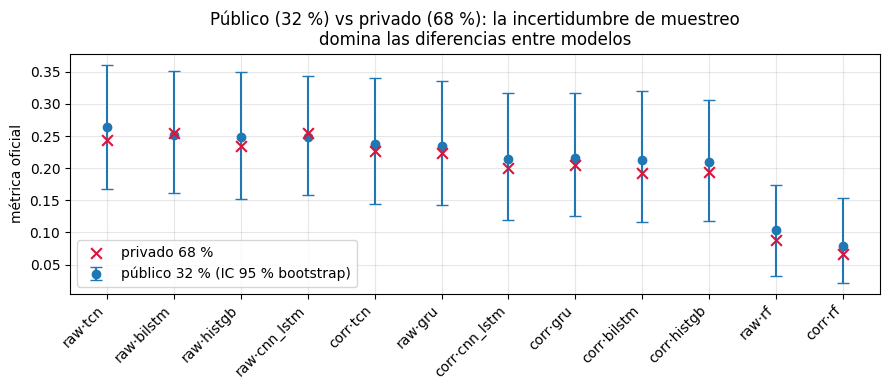

In [6]:
bs = ensure("lb_bootstrap.csv", "bootstrap")
cols = ["condition", "model", "score_full", "score_public_32", "score_private_68",
        "boot_mean", "boot_std", "boot_ci_lo", "boot_ci_hi", "boot_range"]
display(bs[cols].round(4))

gap = (bs.score_public_32 - bs.score_private_68).abs()
print(f"|public - private|: mean {gap.mean():.4f}, max {gap.max():.4f}")
print(f"Mean width of the public 95% CI: {bs.boot_range.mean():.4f}")
spread = bs.groupby("condition").score_full.agg(lambda s: s.max() - s.min())
print("Spread between models (same protocol):", spread.round(4).to_dict())

fig, ax = plt.subplots(figsize=(9, 4))
b = bs.sort_values("score_full", ascending=False)
lbl = b.condition + "·" + b.model
ax.errorbar(range(len(b)), b.boot_mean,
            yerr=[b.boot_mean - b.boot_ci_lo, b.boot_ci_hi - b.boot_mean],
            fmt="o", capsize=4, label="public 32% (bootstrap 95% CI)")
ax.scatter(range(len(b)), b.score_private_68, marker="x", s=60, color="crimson",
           label="private 68%", zorder=3)
ax.set_xticks(range(len(b))); ax.set_xticklabels(lbl, rotation=45, ha="right")
ax.set_ylabel("official metric"); ax.legend(); ax.grid(alpha=.3)
ax.set_title("Public (32%) vs private (68%): the sampling uncertainty\n"
             "dominates the differences between models")
plt.tight_layout(); plt.show()

## §6 O3, active learning under the multi-lab protocol

The same strategies as notebook 06, with the pool and the validation set taken from
this corpus's per-video split, in both conditions. Each strategy is compared against
random sampling with a paired Wilcoxon test over seeds.

In [7]:
al = ensure("lb_al_summary.csv", "al")
display(al.sort_values(["condition", "aulc_mean"], ascending=[True, False]).round(4))
winners = al[(al.strategy != "random") & (al.wilcoxon_p.notna()) & (al.wilcoxon_p < 0.05)
             & (al.delta_vs_random > 0)]
print("Strategies significantly beating random:",
      "none" if winners.empty else winners[["condition", "strategy"]].to_dict("records"))

,condition,strategy,aulc_mean,aulc_std,delta_vs_random,wilcoxon_p
4,corr,margin,0.0465,0.0027,0.0004,1.0000
5,corr,random,0.0461,0.0074,0.0000,NaN
1,corr,coreset,0.0441,0.0071,-0.0020,0.4375
0,corr,badge,0.0426,0.0034,-0.0035,0.4375
2,corr,entropy,0.0400,0.0071,-0.0061,0.1250
3,corr,least_confidence,0.0386,0.0091,-0.0075,0.0625
7,raw,coreset,0.0505,0.0045,0.0002,1.0000
6,raw,badge,0.0504,0.0074,0.0000,1.0000
11,raw,random,0.0503,0.0029,0.0000,NaN
10,raw,margin,0.0462,0.0062,-0.0041,0.3125


Estrategias que baten al azar de forma significativa: ninguna


## §7 O4, generalisation between laboratories

A 9x9 matrix, training on one lab and evaluating on another, scored with the official
metric.

The `n_common_actions` column is what makes the matrix readable: two labs with no
actions in common **cannot** score above zero, so a low cell may mean poor transfer
or simply a disjoint repertoire. The matrix measures both at once.

In [8]:
cl = ensure("lb_crosslab.csv", "crosslab")
for cond in sorted(cl.condition.unique()):
    sub = cl[cl.condition == cond]
    print(f"\n=== {cond} ===")
    display(sub.pivot(index="train_lab", columns="test_lab", values="official").round(3))
    off = sub[sub.train_lab != sub.test_lab]
    print("Mean off the diagonal:",
          off.groupby("train_lab").official.mean().round(3).sort_values(ascending=False).to_dict())
print("\nAction overlap (mean over distinct pairs):",
      round(cl[cl.train_lab != cl.test_lab].n_common_actions.mean(), 2))


=== corr ===


test_lab,CRIM13,CalMS21_supplemental,CalMS21_task1,CalMS21_task2,CautiousGiraffe,ElegantMink,InvincibleJellyfish,JovialSwallow,TranquilPanther
train_lab,,,,,,,,,
CRIM13,0.056,0.021,0.058,0.157,0.000,0.007,0.017,0.051,0.001
CalMS21_supplemental,0.029,0.246,0.064,0.166,0.003,0.028,0.031,0.044,0.050
CalMS21_task1,0.068,0.062,0.094,0.165,0.004,0.030,0.018,0.072,0.043
CalMS21_task2,0.104,0.094,0.133,0.512,0.004,0.034,0.135,0.089,0.026
CautiousGiraffe,0.000,0.000,0.000,0.000,0.002,0.000,0.000,0.000,0.000
ElegantMink,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
InvincibleJellyfish,0.067,0.095,0.071,0.288,0.018,0.027,0.110,0.008,0.013
JovialSwallow,0.001,0.002,0.006,0.003,0.000,0.000,0.000,0.012,0.000
TranquilPanther,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


Media fuera de la diagonal: {'CalMS21_task2': 0.077, 'InvincibleJellyfish': 0.073, 'CalMS21_task1': 0.058, 'CalMS21_supplemental': 0.052, 'CRIM13': 0.039, 'JovialSwallow': 0.002, 'CautiousGiraffe': 0.0, 'ElegantMink': 0.0, 'TranquilPanther': 0.0}

=== raw ===


test_lab,CRIM13,CalMS21_supplemental,CalMS21_task1,CalMS21_task2,CautiousGiraffe,ElegantMink,InvincibleJellyfish,JovialSwallow,TranquilPanther
train_lab,,,,,,,,,
CRIM13,0.105,0.021,0.072,0.195,0.000,0.018,0.016,0.017,0.004
CalMS21_supplemental,0.010,0.230,0.072,0.150,0.000,0.005,0.032,0.007,0.000
CalMS21_task1,0.123,0.052,0.121,0.333,0.014,0.029,0.038,0.061,0.018
CalMS21_task2,0.112,0.055,0.164,0.547,0.014,0.046,0.107,0.083,0.024
CautiousGiraffe,0.000,0.000,0.000,0.000,0.028,0.000,0.000,0.000,0.000
ElegantMink,0.000,0.000,0.000,0.000,0.008,0.100,0.000,0.027,0.002
InvincibleJellyfish,0.049,0.049,0.093,0.292,0.000,0.003,0.116,0.000,0.000
JovialSwallow,0.000,0.004,0.002,0.012,0.000,0.000,0.000,0.040,0.002
TranquilPanther,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


Media fuera de la diagonal: {'CalMS21_task1': 0.084, 'CalMS21_task2': 0.076, 'InvincibleJellyfish': 0.061, 'CRIM13': 0.043, 'CalMS21_supplemental': 0.035, 'ElegantMink': 0.005, 'JovialSwallow': 0.002, 'CautiousGiraffe': 0.0, 'TranquilPanther': 0.0}

Solapamiento de acciones (media de pares distintos): 2.25


## §8 Computational cost

The first runtime measurement in the project: until now only the correction pipeline
recorded timings, never the classifiers. Reports the cost of building the caches,
which is where the correction lives, and of training and predicting with each
model.

In [9]:
rt = pd.read_csv(RESULTS / "lb_runtime_cache.csv")
agg = rt.groupby("variant").agg(videos=("video_id", "nunique"), frames=("n_frames", "sum"),
                                windows=("n_windows", "sum"), total_s=("elapsed_s", "sum"),
                                ms_per_frame=("ms_per_frame", "mean")).round(2)
display(agg)
print("Overhead of the correction: "
      f"x{agg.loc['corr','ms_per_frame'] / max(agg.loc['raw','ms_per_frame'], 1e-9):.0f} "
      "in ms/frame against using the raw tracking.")

mods = pd.read_csv(RESULTS / "lb_models.csv")
display(mods.pivot(index="model", columns="condition", values="fit_predict_s").round(1))

,vídeos,frames,ventanas,total_s,ms_por_frame
variant,,,,,
corr,89,768714,41568,20776.54,27.05
raw,90,768714,34979,111.55,0.73


Sobrecoste de la corrección: x37 en ms/frame frente a usar el tracking crudo.


condition,corr,raw
model,,
bilstm,2025.6,2004.0
cnn_lstm,3919.6,3912.2
gru,315.8,314.4
histgb,51.9,54.0
rf,17.2,20.1
tcn,2040.9,2034.6


## §9 Reading it together

Four things this notebook can establish that no earlier section could:

1. **A number comparable with the leaderboard**, under the official metric and
   averaged across laboratories, instead of a per-window F1 from a single lab.
2. **The windowing ceiling (§2)**, the upper bound imposed by reconstructing
   intervals from 64/32 windows. No model can pass it, so it is the honest
   denominator for every result in §4.
3. **The public-private uncertainty (§5)**, which says whether the differences
   between models survive sampling 32% of the test set.
4. **The effect of the correction on all four objectives at once**, under a single
   protocol, with its computational cost alongside.